In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
init_printing()

### Formatting note:
I have produced this pdf by converting the jupyter notebook with my code to a PDF, this may have made the formatting slightly strange. I am happy to reformat this into a LaTeX doc if need be.

# Problem 1

1. (a) First, by inspection we can easily see that (a), (b), and (c) are strongly connected. (a) and (c) both have paths that go around through all nodes, and in (b) any node can get to any other node by going through node 1. (d) is not strongly connected because there is no path out of node 6.

 The adjacency matricies for each graph, which I've computed by hand, are:

In [2]:
Aa = np.array([[0,1,1,0,0,1,1],[1,0,1,1,0,0,1],[1,1,0,1,1,0,0],[0,1,1,0,1,1,0],[0,0,1,1,0,1,1],[1,0,0,1,1,0,1],[1,1,0,0,1,1,0]])
Ab = np.array([[0,1,1,1,1,1,1],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0]])
Ac = np.array([[0,1,1,0,1,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1],[1,0,0,0,0,0,0]]).T
Ad = np.array([[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[1,0,0,0,0,0,0],[0,0,0,0,1,0,0],[0,0,0,1,0,0,0],[1,0,0,1,0,0,1],[1,0,0,1,0,0,0]])

print("Adjacency matrix for (a):")
sym.Matrix(Aa)

Adjacency matrix for (a):


⎡0  1  1  0  0  1  1⎤
⎢                   ⎥
⎢1  0  1  1  0  0  1⎥
⎢                   ⎥
⎢1  1  0  1  1  0  0⎥
⎢                   ⎥
⎢0  1  1  0  1  1  0⎥
⎢                   ⎥
⎢0  0  1  1  0  1  1⎥
⎢                   ⎥
⎢1  0  0  1  1  0  1⎥
⎢                   ⎥
⎣1  1  0  0  1  1  0⎦

In [5]:
print("Adjacency matrix for (b):")
sym.Matrix(Ab)

Adjacency matrix for (b):


⎡0  1  1  1  1  1  1⎤
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎣1  0  0  0  0  0  0⎦

In [5]:
print("Adjacency matrix for (c):")
sym.Matrix(Ac)

Adjacency matrix for (c):


⎡0  0  0  0  0  0  1⎤
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎣0  0  0  0  0  1  0⎦

In [6]:
print("Adjacency matrix for (d):")
sym.Matrix(Ad)

Adjacency matrix for (d):


⎡0  1  0  0  0  0  0⎤
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢1  0  0  1  0  0  1⎥
⎢                   ⎥
⎣1  0  0  1  0  0  0⎦

It is easy to compute $\Delta$ and $L$ now that we have all of the adjacency matricies:

In [7]:
def get_D_L(A):
    # there's no real reason to code for this part of the problem but maybe this will be handy to have on hand in the future
    # and I don't want to make all these matricies in LaTeX
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) # i LOVE list comprehensions, even though would probably be faster to do something like np.diag(A@np.ones(n))
    L = D-A
    return D,L

Da,La = get_D_L(Aa)
Db,Lb = get_D_L(Ab)
Dc,Lc = get_D_L(Ac)
Dd,Ld = get_D_L(Ad)

print("Degree matrix for (a):")
sym.Matrix(Da)

Degree matrix for (a):


⎡4  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  4  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  4  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  4  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  4  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  4  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  4⎦

In [8]:
print("Degree matrix for (b):")
sym.Matrix(Db)

Degree matrix for (b):


⎡6  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  1  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  1⎦

In [9]:
print("Degree matrix for (c):")
sym.Matrix(Dc)

Degree matrix for (c):


⎡1  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  2  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  2  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  1  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  1⎦

In [10]:
print("Degree matrix for (d):")
sym.Matrix(Dd)

Degree matrix for (d):


⎡1  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  3  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  2⎦

In [11]:
print("Laplacian matrix for (a):")
sym.Matrix(La)

Laplacian matrix for (a):


⎡4   -1  -1  0   0   -1  -1⎤
⎢                          ⎥
⎢-1  4   -1  -1  0   0   -1⎥
⎢                          ⎥
⎢-1  -1  4   -1  -1  0   0 ⎥
⎢                          ⎥
⎢0   -1  -1  4   -1  -1  0 ⎥
⎢                          ⎥
⎢0   0   -1  -1  4   -1  -1⎥
⎢                          ⎥
⎢-1  0   0   -1  -1  4   -1⎥
⎢                          ⎥
⎣-1  -1  0   0   -1  -1  4 ⎦

In [12]:
print("Laplacian matrix for (b):")
sym.Matrix(Lb)

Laplacian matrix for (b):


⎡6   -1  -1  -1  -1  -1  -1⎤
⎢                          ⎥
⎢-1  1   0   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   1   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   1   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   0   1   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   0   0   1   0 ⎥
⎢                          ⎥
⎣-1  0   0   0   0   0   1 ⎦

In [13]:
print("Laplacian matrix for (c):")
sym.Matrix(Lc)

Laplacian matrix for (c):


⎡1   0   0   0   0   0   -1⎤
⎢                          ⎥
⎢-1  1   0   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  -1  2   0   0   0   0 ⎥
⎢                          ⎥
⎢0   0   -1  1   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   -1  2   0   0 ⎥
⎢                          ⎥
⎢0   0   0   0   -1  1   0 ⎥
⎢                          ⎥
⎣0   0   0   0   0   -1  1 ⎦

In [14]:
print("Laplacian matrix for (d):")
sym.Matrix(Ld)

Laplacian matrix for (d):


⎡1   -1  0   0   0   0  0 ⎤
⎢                         ⎥
⎢0   1   -1  0   0   0  0 ⎥
⎢                         ⎥
⎢-1  0   1   0   0   0  0 ⎥
⎢                         ⎥
⎢0   0   0   1   -1  0  0 ⎥
⎢                         ⎥
⎢0   0   0   -1  1   0  0 ⎥
⎢                         ⎥
⎢-1  0   0   -1  0   3  -1⎥
⎢                         ⎥
⎣-1  0   0   -1  0   0  2 ⎦

(b) Here I have computed the eigenvalues of $L$ numerically:

In [15]:
def eval_calculator(A):
    n = A.shape[1]
    evals = np.linalg.eigvals(A)
    evals[abs(evals)<0.0000001]=0.0 # make things close to zero appear as zero
    return evals

print("Eigenvalues of L for (a):")
sym.Matrix(eval_calculator(La))

Eigenvalues of L for (a):


⎡      0.0       ⎤
⎢                ⎥
⎢6.24697960371747⎥
⎢                ⎥
⎢3.19806226419516⎥
⎢                ⎥
⎢4.55495813208737⎥
⎢                ⎥
⎢6.24697960371747⎥
⎢                ⎥
⎢4.55495813208737⎥
⎢                ⎥
⎣3.19806226419516⎦

In [16]:
print("Eigenvalues of L for (b):")
sym.Matrix(eval_calculator(Lb))

Eigenvalues of L for (b):


⎡7.0⎤
⎢   ⎥
⎢0.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎣1.0⎦

In [17]:
print("Eigenvalues of L for (c):")
sym.Matrix(eval_calculator(Lc))

Eigenvalues of L for (c):


⎡                   0                   ⎤
⎢                                       ⎥
⎢0.767214384061616 + 0.792551992515449⋅ⅈ⎥
⎢                                       ⎥
⎢0.767214384061616 - 0.792551992515449⋅ⅈ⎥
⎢                                       ⎥
⎢           2.46557123187677            ⎥
⎢                                       ⎥
⎢       1.5 + 0.866025403784439⋅ⅈ       ⎥
⎢                                       ⎥
⎢       1.5 - 0.866025403784439⋅ⅈ       ⎥
⎢                                       ⎥
⎣                  2.0                  ⎦

In [18]:
print("Eigenvalues of L for (d):")
sym.Matrix(eval_calculator(Ld))

Eigenvalues of L for (d):


⎡           3.0           ⎤
⎢                         ⎥
⎢           2.0           ⎥
⎢                         ⎥
⎢            0            ⎥
⎢                         ⎥
⎢1.5 + 0.866025403784439⋅ⅈ⎥
⎢                         ⎥
⎢1.5 - 0.866025403784439⋅ⅈ⎥
⎢                         ⎥
⎢           2.0           ⎥
⎢                         ⎥
⎣            0            ⎦

(c) Here I use a function I wrote to solve the problem for (a), (b), (c). I also compute $\mathbf{w}^\top L = 0$ and $\mathbf{w}^\top \mathbf{1}=1$ to verify the solution is correct.

In [19]:
def find_w(L):
    vals, vecs = np.linalg.eig(L.T)
    w = vecs.T[np.argmin(np.abs(vals))] # select eigvec with associated zero eigenvalue
    return w/(w.T@np.ones(7)) # normalize

wa = find_w(La)
print("w for (a): ",wa)
print("w^T1=",wa@np.ones(7))
z = La.T@wa
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (a):  [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
w^T1= 1.0
w^TL= [0. 0. 0. 0. 0. 0. 0.]


In [20]:
wb = find_w(Lb)
print("w for (b): ",wb)
print("w^T1=",wb@np.ones(7))
z = Lb.T@wb
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (b):  [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
w^T1= 1.0000000000000002
w^TL= [0. 0. 0. 0. 0. 0. 0.]


In [21]:
wc = find_w(Lc)
print("w for (c): ",wc)
print("w^T1=",wc@np.ones(7))
z = Lc.T@wc
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (c):  [0.22222222+0.j 0.05555556+0.j 0.05555556+0.j 0.11111111+0.j
 0.11111111+0.j 0.22222222+0.j 0.22222222+0.j]
w^T1= (1+0j)
w^TL= [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


For (d) we have to be a little more careful. There are 2 zero eigenvalues, so we can find two such w vectors.

In [22]:
vals,vecs = np.linalg.eig(Ld.T)
#print(vals) # print this to see the right index for zero eigenvalues

In [63]:
wd1 = vecs.T[0]
wd2 = vecs.T[4]
wd1 = wd1/(wd1@np.ones(7))
wd2 = wd2/(wd2@np.ones(7))

print("w_1 for (d): ",wd1)
print("w_2 for (d): ",wd2)

print("------")

print("w^T1=1 check for w_1,w_2",wd1@np.ones(7),wd2@np.ones(7))

z1 = Ld.T@wd1
z1[np.abs(z1)<0.000001]=0
z2 = Ld.T@wd2
z2[np.abs(z1)<0.000001]=0
print("w_1^TL=0 check:",z1)
print("w_2^TL=0 check:",z2)

w_1 for (d):  [ 0.33333333-0.j  0.33333333-0.j  0.33333333-0.j -0.        -0.j
 -0.        -0.j -0.        -0.j -0.        -0.j]
w_2 for (d):  [0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
------
w^T1=1 check for w_1,w_2 (1+0j) (1+0j)
w_1^TL=0 check: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
w_2^TL=0 check: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


(d)

Graphs (a) and (b) are undirected (every edge points both directions with the same weight), so they are automatically weight-balanced since their adjacency matrix is symmetric. (d) cannot be made weight balanced without changing the topology of the graph since it is not strongly connected, i.e. there is no way to balance node 6 since there are no arrows pointing from it.

Graph (c), on the other hand is not weight balanced, note the in degree of node 1 is 1 while its out degree is 3. However we can come up with some weights that make this weight balanced without changing the graph topology:

In [24]:
Ahat = np.array([[0,0,0,0,0,0,2],[1/2,0,0,0,0,0,0],[1/2,1/2,0,0,0,0,0],[0,0,1,0,0,0,0],[1,0,0,1,0,0,0],[0,0,0,0,2,0,0],[0,0,0,0,0,2,0]])

print("Weight balanced adjacency matrix for (c), called A hat:")
sym.Matrix(Ahat)

Weight balanced adjacency matrix for (c), called A hat:


⎡0.0  0.0  0.0  0.0  0.0  0.0  2.0⎤
⎢                                 ⎥
⎢0.5  0.0  0.0  0.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.5  0.5  0.0  0.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  1.0  0.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢1.0  0.0  0.0  1.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  0.0  0.0  2.0  0.0  0.0⎥
⎢                                 ⎥
⎣0.0  0.0  0.0  0.0  0.0  2.0  0.0⎦

I figured out these weights by hand, similar to how one would solve a sudoku puzzle, though one coud approach this more systematically as well, such as following the procedure in Bullo's Lectures on Network Systems section 7.4.

We can check to make sure that I am telling the truth and this is in fact weight balanced:

In [25]:
print("Returns all true if weight balanced:",Ahat@np.ones(7) == np.ones(7).T@Ahat)

Returns all true if weight balanced: [ True  True  True  True  True  True  True]


In [26]:
Dhat,Lhat = get_D_L(Ahat)

print("Degree matrix corresponding to A hat:")
sym.Matrix(Dhat)

Degree matrix corresponding to A hat:


⎡2.0  0.0  0.0  0.0  0.0  0.0  0.0⎤
⎢                                 ⎥
⎢0.0  0.5  0.0  0.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  1.0  0.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  0.0  1.0  0.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  0.0  0.0  2.0  0.0  0.0⎥
⎢                                 ⎥
⎢0.0  0.0  0.0  0.0  0.0  2.0  0.0⎥
⎢                                 ⎥
⎣0.0  0.0  0.0  0.0  0.0  0.0  2.0⎦

In [27]:
print("Laplacian matrix corresponding to A hat")
sym.Matrix(Lhat)

Laplacian matrix corresponding to A hat


⎡2.0   0.0   0.0   0.0   0.0   0.0   -2.0⎤
⎢                                        ⎥
⎢-0.5  0.5   0.0   0.0   0.0   0.0   0.0 ⎥
⎢                                        ⎥
⎢-0.5  -0.5  1.0   0.0   0.0   0.0   0.0 ⎥
⎢                                        ⎥
⎢0.0   0.0   -1.0  1.0   0.0   0.0   0.0 ⎥
⎢                                        ⎥
⎢-1.0  0.0   0.0   -1.0  2.0   0.0   0.0 ⎥
⎢                                        ⎥
⎢0.0   0.0   0.0   0.0   -2.0  2.0   0.0 ⎥
⎢                                        ⎥
⎣0.0   0.0   0.0   0.0   0.0   -2.0  2.0 ⎦

2. 

(a) The graphs (a), (b), and (c) will reach consensus, because they are strongly connected. (d) is not strongly connected so it may not reach consensus. The first two graphs are weight balanced, so they also will converge to an average of the initial condition.

(b) We can compute this by taking the dot product of the w vectors we found above with the initial condition. I've also calculated the average of the initial condition so we can see the predicted consensus value is the same as the average for graphs (a) and (b).

In [28]:
x0 = np.array([1,2,3,4,5,6,7])
avg = 1/7 * sum(x0)
print("average of initial condition =", avg)
print("-----------")

consensus_a = wa.T@x0
print("consensus alpha for (a) =",consensus_a)
print("-----------")
consensus_b = wb.T@x0
print("consensus alpha for (b) =",consensus_b)
print("-----------")
consensus_c = wc.T@x0
print("consensus alpha for (c) =",consensus_c)

average of initial condition = 4.0
-----------
consensus alpha for (a) = 4.0
-----------
consensus alpha for (b) = 4.000000000000001
-----------
consensus alpha for (c) = (4.388888888888888+0j)


(c) The slowest decay rate is determined by $\lambda_2$, the nonzero eigenvalue of $L$ with the smallest real part.These can be extracted from the eigenvalue calculation we did above:

In [29]:
E=eval_calculator(La)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (a)=",lam_2)

E=eval_calculator(Lb)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (b)=",lam_2)

E=eval_calculator(Lc)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (c)=",lam_2)

Re(lambda_2) for (a)= 3.1980622641951615
Re(lambda_2) for (b)= 0.9999999999999998
Re(lambda_2) for (c)= 0.7672143840616164


Since the slowest decay looks like $e^{-\lambda_2 t}$, larger values for $\lambda_2$ decay quicker. Therefore (a) should reach consensus fastest, followed by (b) and then (c).

3. 

(a) For these simulations I use scipy's `solve_ivp` function.

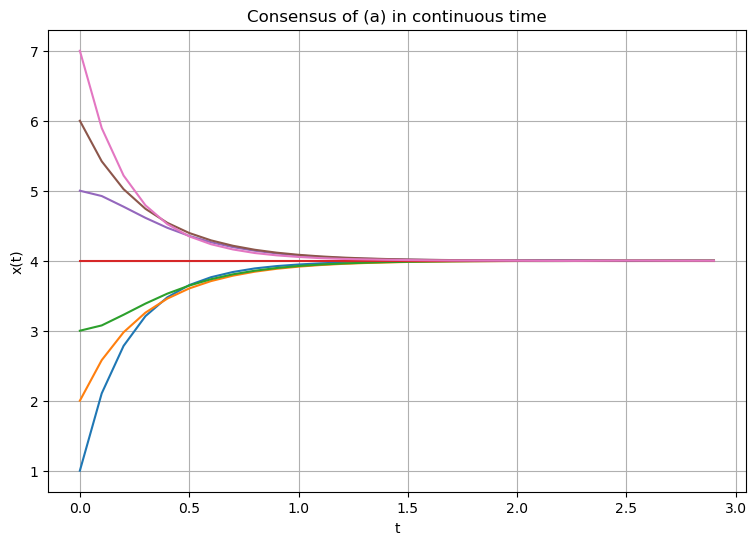

In [64]:
def f1(t,x):
    return -La@x

tspan = (0,3)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.title("Consensus of (a) in continuous time")
plt.xlabel("t")
plt.show()

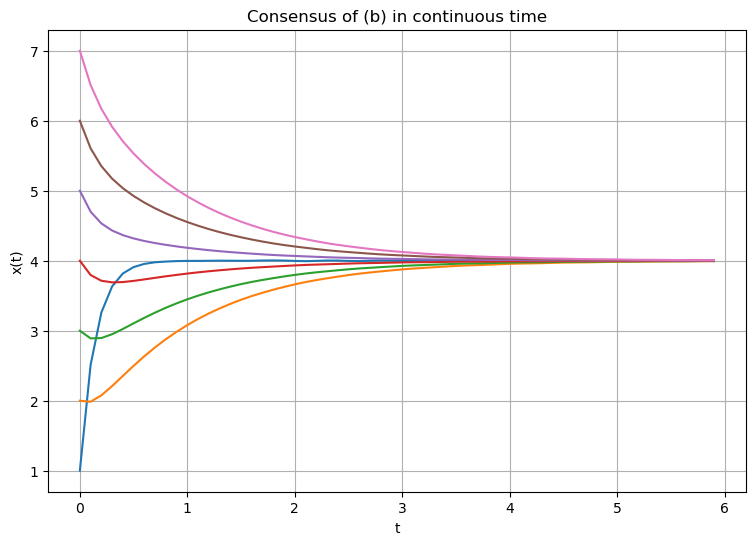

In [65]:
def f1(t,x):
    return -Lb@x

tspan = (0,6)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("Consensus of (b) in continuous time")
plt.show()

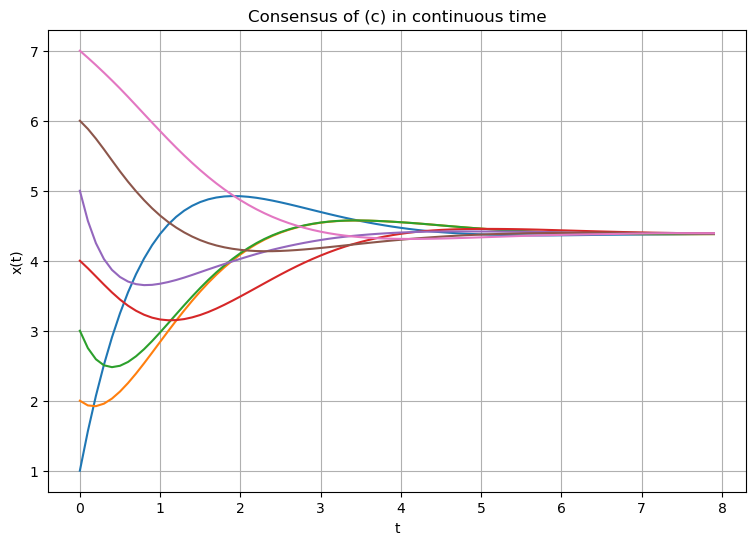

In [66]:
def f1(t,x):
    return -Lc@x

tspan = (0,8)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("Consensus of (c) in continuous time")
plt.show()

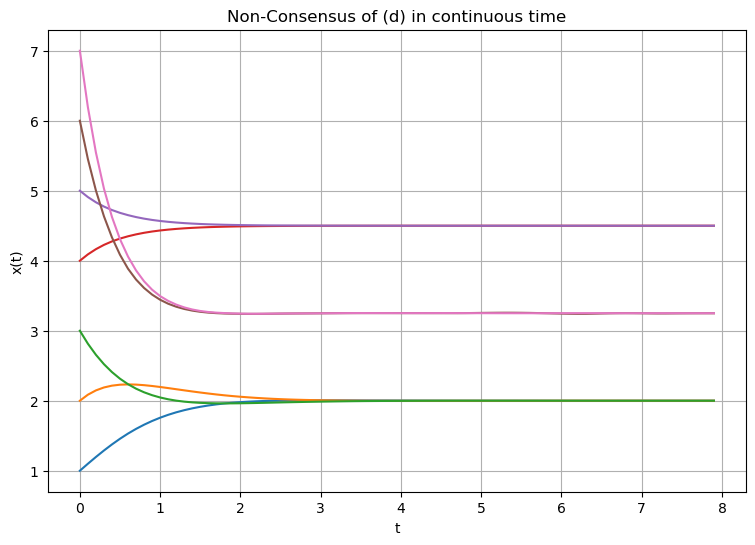

In [67]:
def f1(t,x):
    return -Ld@x

tspan = (0,8)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("Non-Consensus of (d) in continuous time")
plt.show()

(b) The simulation, shown below, now converges to the average, unlike above in the unweighted case.

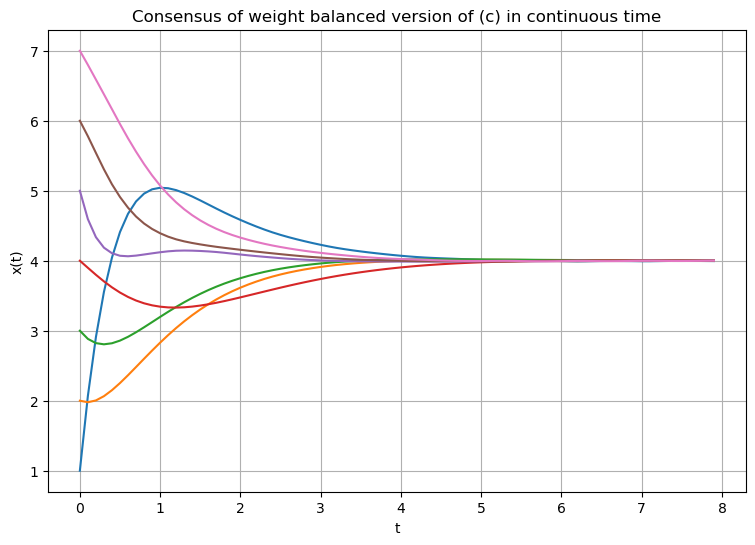

In [68]:
def f1(t,x):
    return -Lhat@x

tspan = (0,8)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("Consensus of weight balanced version of (c) in continuous time")
plt.show()

(c) This time I wrote my own code to run the simulation. Here are the results:

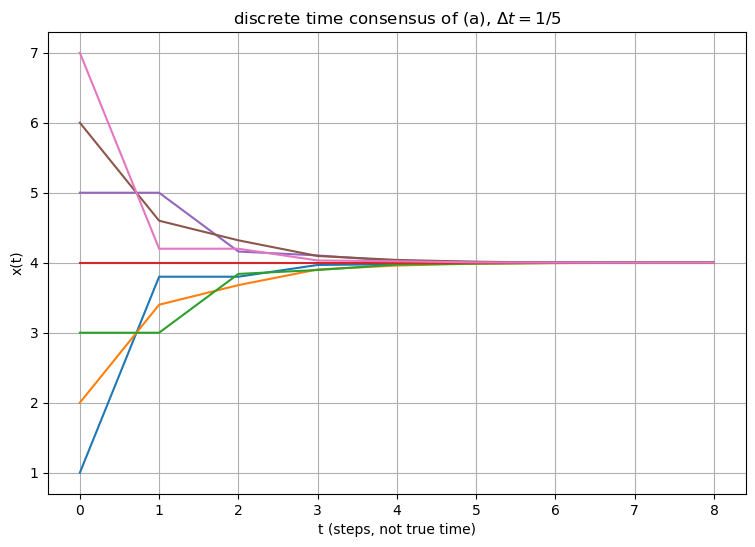

In [69]:
def simulate_discrete(L,x0,dt,tf):
    W = np.identity(7)-dt*L
    lst = [x0]
    t =0
    x = x0
    while t <=tf:
        x = W@x
        lst.append(x)
        t += dt
    return np.asarray(lst)

lst = simulate_discrete(La,x0,1/5, 1.5)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t (steps, not true time)")
plt.title(r"discrete time consensus of (a), $\Delta t = 1/5$")
plt.show()

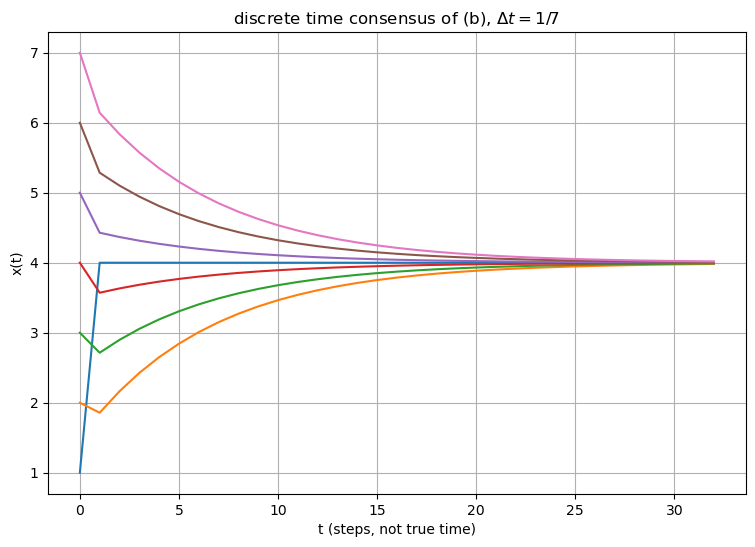

In [70]:
lst = simulate_discrete(Lb,x0,1/7, 4.5)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t (steps, not true time)")
plt.title(r"discrete time consensus of (b), $\Delta t = 1/7$")
plt.show()

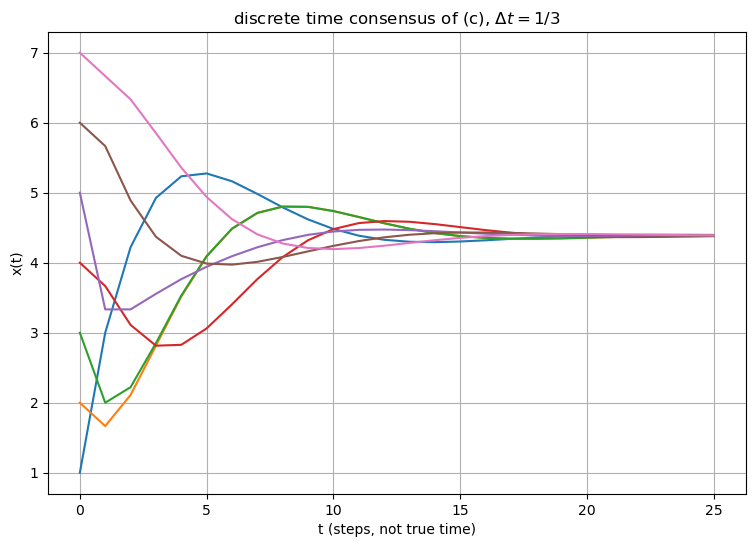

In [71]:
lst = simulate_discrete(Lc,x0,1/3, 8)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (c), $\Delta t = 1/3$")
plt.xlabel("t (steps, not true time)")
plt.show()

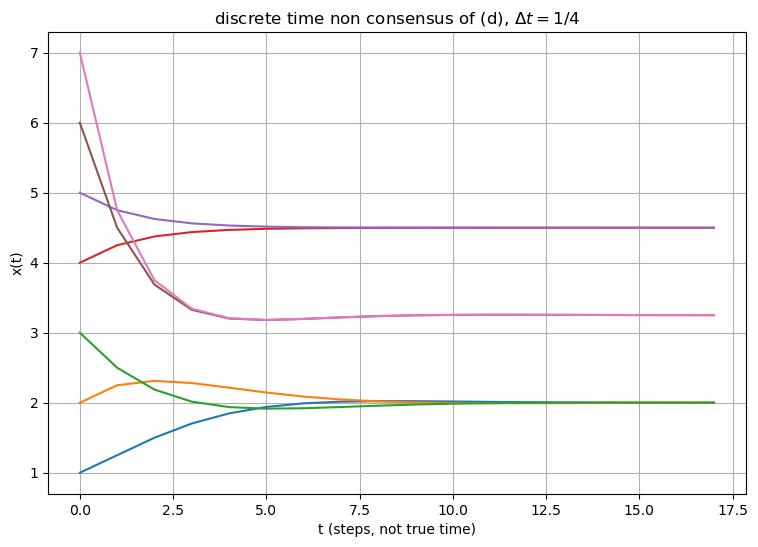

In [72]:
lst = simulate_discrete(Ld,x0,1/4, 4)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time non consensus of (d), $\Delta t = 1/4$")
plt.xlabel("t (steps, not true time)")
plt.show()

To choose the time steps, I looked at the maximal in degree, $d_{max}$, then set the time step to be $\frac{1}{d_{max}+1}$. We know from class that this is an adequatley small time step to ensure the euler discretization is stable. Of course I also could have chosen these using the $\frac{2}{\lambda_{max}}$ bound, but since in this case it is so easy to see the maximum degree I just went with that.

We could choose a smaller time step, say 1/8 for (c):

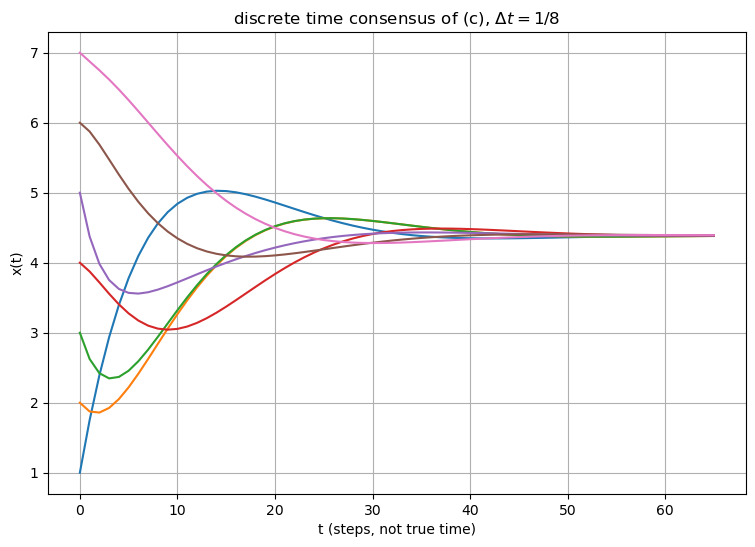

In [73]:
lst = simulate_discrete(Lc,x0,1/8, 8)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (c), $\Delta t = 1/8$")
plt.xlabel("t (steps, not true time)")
plt.show()

By inspecting the graphs, it is clear that choosing a smaller time step requires more iterations to converge. With $\Delta t = 1/8$, consensus is reached in around 60 iterations, while it only takes around 25 with $\Delta t = 1/3$.

4. This is mostly a matter of coding. Since both (a) and (b) are strongly connected and weight balanced, we still expect convergence to the average. My switching rule will be to switch uniformly at random with probability 1/4.

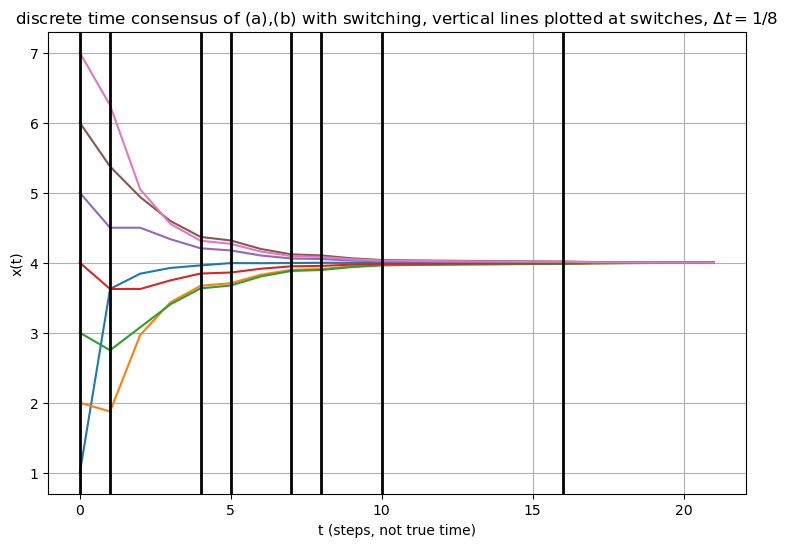

In [74]:
p = 1/4

def simulate_discrete_switching(L1,L2,x0,dt,tf,mode=0,p=1/4):
    # I'm sure there is a more optimal way of doing this... but this works so its fine
    lst = [x0]
    x = x0
    t=0
    W1 = np.identity(7)-dt*L1
    W2 = np.identity(7)-dt*L2
    modes = [mode]

    while t<=tf:
        if np.random.rand() <= p:
            mode = (mode+1)%2
        
        if mode == 0:
            x = W1@x
        elif mode == 1:
            x = W2@x
        lst.append(x)
        t+=dt
        modes.append(mode)
    return np.asarray(lst),modes

lst,modes = simulate_discrete_switching(La,Lb,x0,1/8,2.5,mode=0,p=1/3)


plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])

for i in range(len(modes)-1):
    if modes[i] != modes[i+1]:
        plt.axvline(i,zorder = 2,color = "black",lw = 2)

plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (a),(b) with switching, vertical lines plotted at switches, $\Delta t = 1/8$")
#plt.legend()
plt.xlabel("t (steps, not true time)")
plt.show()

As expected, consensus to the average is reached.

It seems the convergence with switching is faster than how long it takes (b) to converge, even though I'm using a smaller time step! It is taking longer than it took (a) to converge, but I am using a much smaller time step.

# Problem 2

1. Let's begin by loading in the layout of the room and plot it using the plotting function provided with the assignment.

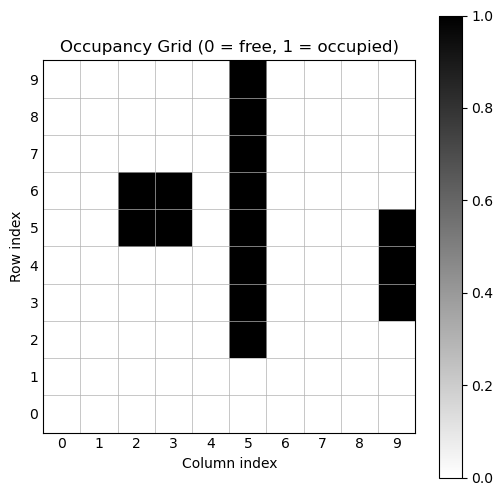

In [41]:
room_10x10 = np.loadtxt("room_10x10.csv",int,delimiter=",") #indexes by row, column from top left

# plotting function provided with assignment
def plot_occupancy(grid, title="Occupancy Grid (0 = free, 1 = occupied)",cmap = "binary"):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(grid, origin='lower', interpolation='none', cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Column index')
    ax.set_ylabel('Row index')
    ax.set_xticks(np.arange(0, grid.shape[1], 1))
    ax.set_yticks(np.arange(0, grid.shape[0], 1))
    # Draw gridlines at cell boundaries
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.5)
    ax.tick_params(axis='both', which='both', length=0)
    fig.colorbar(im) # added this in because I like being able to see the colorbar
    plt.show()
    
plot_occupancy(room_10x10)

For the function to check if two points on the grid are connected by a line that dosen't pass through any of the barriers (excluding endpoints), I've written a function that parameterizes a line from the center of the first point to the last and checks at each point along the line what grid point the point of the line is in. Then it selects only the unique grid points the line passes through and excludes the last one (the endppoint). If any of these grid points are where there is a barrier the function returns false and it returns true otherwise. It is worth noting that the number of points used for the parameterized line is a choice, and should be chosen large enough such that no grid point is skipped over by the line.

In [42]:
def check_connected(rcA,rcB,n,h,room_10x10):
    t = np.linspace(0,1,n)[:, None] # time array for parameterizing line
    line = rcA*(1-t) + rcB*t # parameterized ray
    indexes = np.floor(line/h) # compute the grid indicies the line goes through
    new = [list(i) for i in indexes] # for uniqueness
    indexes = np.unique(new,axis=0) # keep only unique grid indicies the line goes through
    truth = True
    for i in range(len(indexes)-1): # minus one to not include endpoint square
        id = indexes[i]
        if int(room_10x10[int(id[0]),int(id[1])]) == 1: # return false if line (not endpoint) hits a barrier
            truth = False
    return truth

phit = 0.85
pfa = 0.1
def measurement_prob(rc,room_10x10):
    r =int(rc[0])
    c = int(rc[1])
    x = np.random.rand()
    if room_10x10[r,c] == 1 and x <=phit:
        return 1
    elif room_10x10[r,c]==1 and x>phit:
        return 0
    elif room_10x10[r,c]==0 and x<= pfa:
        return 1
    else:
        return 0


2. We can use the function from the previous part and the provided visualization function to see the line of sight of each robot:

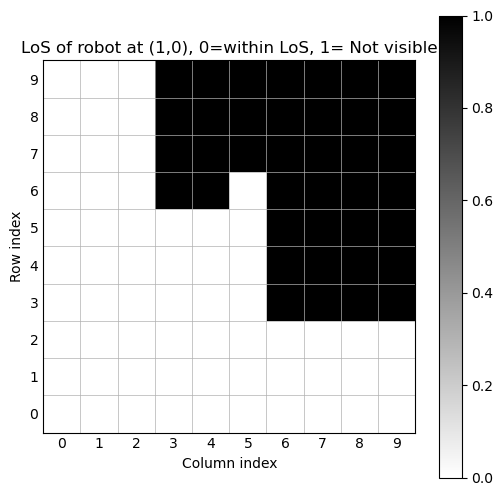

In [43]:
def get_LoS(robot_rc,room_10x10,n,h):
    #r,c = int(robot_rc[0]),int(robot_rc[1])
    LoS = np.zeros_like(room_10x10)
    shape = np.shape(room_10x10)
    for i in range(shape[0]):
        for j in range(shape[1]):
            truth = check_connected(robot_rc,(i,j),n,h,room_10x10)
            if truth == True:
                LoS[i,j]=0
            else:
                LoS[i,j]=1
    return LoS

LoS10 = get_LoS((1,0),room_10x10,20,1)
LoS18 = get_LoS((1,8),room_10x10,20,1)
LoS70 = get_LoS((7,0),room_10x10,20,1)
LoS88 = get_LoS((8,8),room_10x10,20,1)
LoS_lst = [LoS10,LoS18,LoS70,LoS88]

plot_occupancy(LoS10,"LoS of robot at (1,0), 0=within LoS, 1= Not visible")

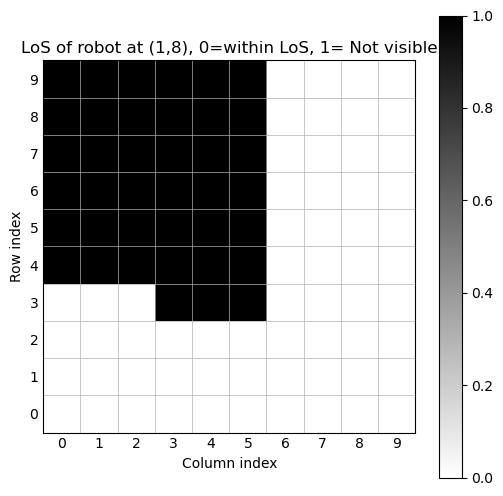

In [44]:
plot_occupancy(LoS18,"LoS of robot at (1,8), 0=within LoS, 1= Not visible")

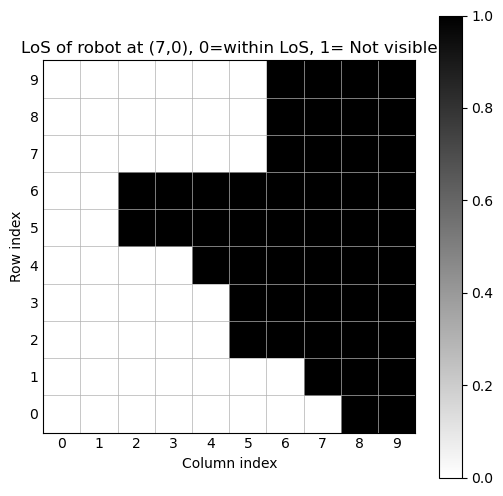

In [45]:
plot_occupancy(LoS70,"LoS of robot at (7,0), 0=within LoS, 1= Not visible")

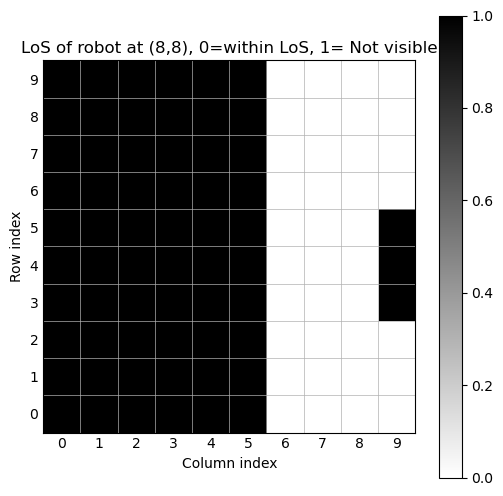

In [46]:
plot_occupancy(LoS88,"LoS of robot at (8,8), 0=within LoS, 1= Not visible")

3. Here I've written a function that does this for robot $i$.

In [47]:
def bayes_step(i,xik):
    Vi = LoS_lst[i]
    for k in range(10):
        for j in range(10):
            if int(Vi[k,j])==1: # only measure things you can see
                pass
            else:
                m = measurement_prob((k,j),room_10x10)
                if m == 1:
                    xik[k,j] += np.log(phit/pfa)
                else:
                    xik[k,j] += np.log((1-phit)/(1-pfa))
    return xik

p0 = 0.5
p0log = np.log(p0/(1-p0))
x0_lst = [p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10)]
print(p0log)

0.0


4.

First, we need to compute the metropolis weights. First let's use the `check_connected` function to see which robots can see each other:

In [48]:
robot_locations = np.array([[1,0],[1,8],[7,0],[8,8]])
for i in range(4):
    for j in range(4):
        if i == j:
            pass
        else:
            truth = check_connected(robot_locations[i],robot_locations[j],20,1,room_10x10)
            if truth == True:
                print("robot " + str(i) + " can see robot " + str(j) )

robot 0 can see robot 1
robot 0 can see robot 2
robot 1 can see robot 0
robot 1 can see robot 3
robot 2 can see robot 0
robot 3 can see robot 1


This means our adjacency matrix is:

In [49]:
A = np.array([[0,1,1,0],[1,0,0,1],[1,0,0,0],[0,1,0,0]])
sym.Matrix(A)

⎡0  1  1  0⎤
⎢          ⎥
⎢1  0  0  1⎥
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎣0  1  0  0⎦

We can now compute metropolis weights:

In [50]:
D,L = get_D_L(A)

w = np.zeros_like(A,float) # float is important or everything gets screwed up, rounded to ints
for i in range(4):
    for j in range(4):
           if i != j and A[i,j] == 1:
               w[i,j] = 1/(1+ np.array([D[i,i], D[j,j]]).max())
    w[i,i] = 1 - sum(w[i])

sym.Matrix(w)

⎡0.333333333333333  0.333333333333333  0.333333333333333         0.0       ⎤
⎢                                                                          ⎥
⎢0.333333333333333  0.333333333333333         0.0         0.333333333333333⎥
⎢                                                                          ⎥
⎢0.333333333333333         0.0         0.666666666666667         0.0       ⎥
⎢                                                                          ⎥
⎣       0.0         0.333333333333333         0.0         0.666666666666667⎦

I'll also write a function that does the averaging over the network:

In [51]:
def average(i,xik_lst,w):
    lst = []
    for j in range(4):
        lst.append(w[i,j]*xik_lst[j]) # have to be careful to do this calculation independently 
        # probably there is a smarter/faster way to do this but this works so its fine
    return sum(lst)

And finally a function that puts it all together and runs the simulation.

In [52]:
p0 = 0.5
p0log = np.log(p0/(1-p0))
x_lst = [p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10)]

def simulate_cooperative_bayes(x_lst,K=20):
    for t in range(K):
        for i in range(4):
            xik = x_lst[i] 
            xik = bayes_step(i,xik) # measure and local update
            xik = average(i,x_lst,w) # consensus
            x_lst[i] = xik
    return x_lst

x_lst = simulate_cooperative_bayes(x_lst)

5. After converting back to probability, here are the results visualized:

In [53]:
p_lst = []
for i in range(4):
    p_lst.append(1/(1+np.exp(-x_lst[i])))

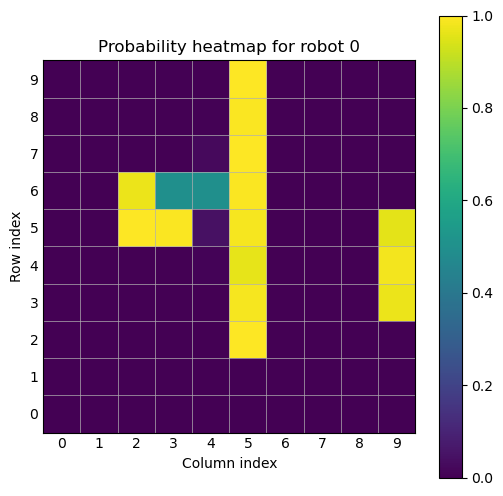

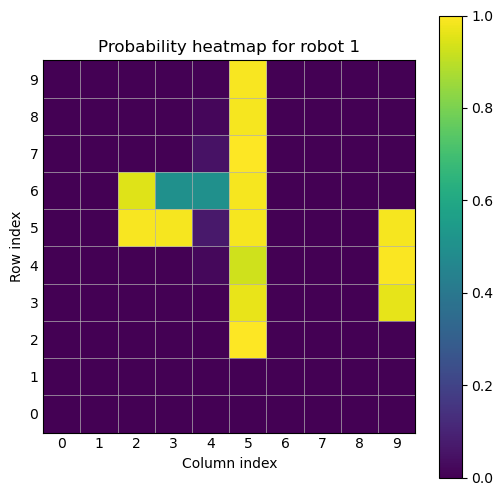

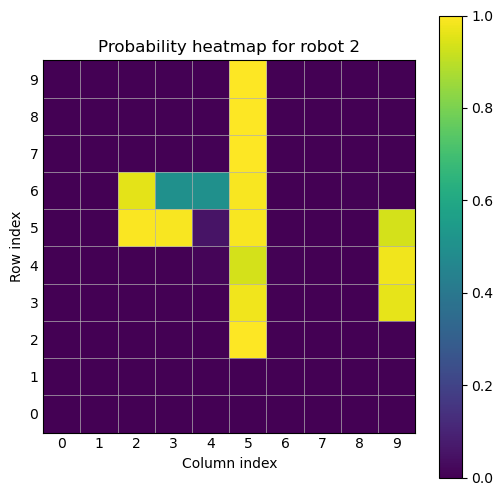

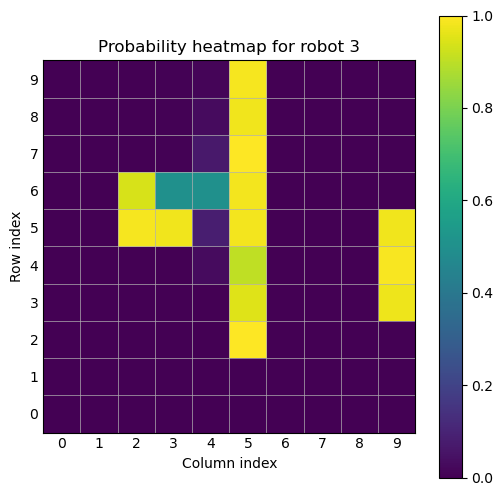

In [54]:
for i in range(4):
    plot_occupancy(p_lst[i],"Probability heatmap for robot " + str(i),cmap = "viridis")
    

The robots are able to construct everything that they can see! A couple cells remain with the original probability of 0.5, but that is because those cells are not seen by any of the four robots.

Here are the binary maps:

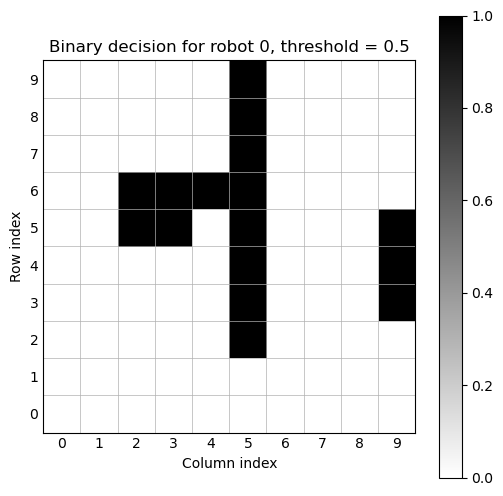

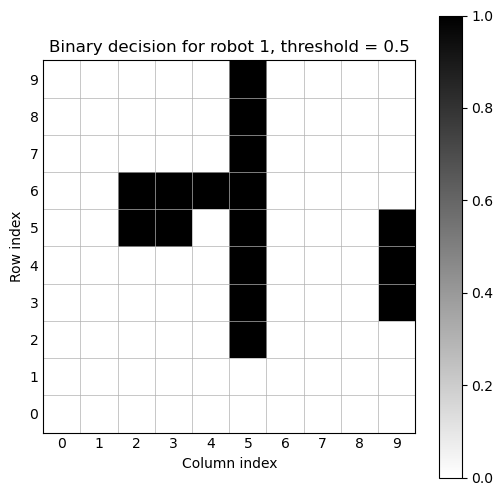

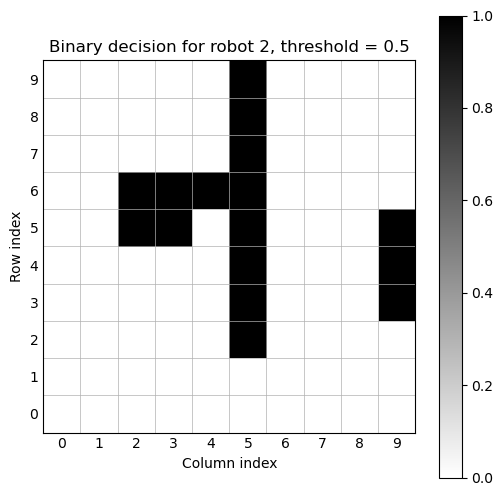

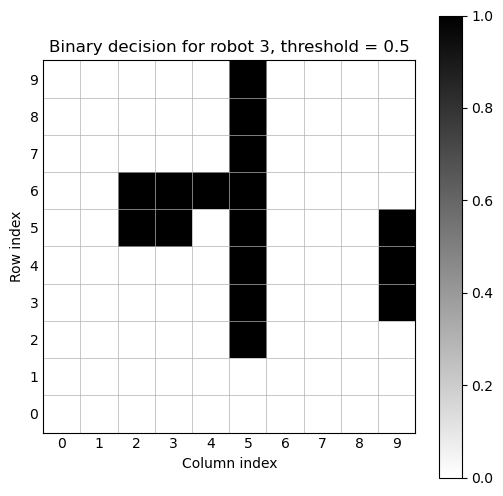

In [55]:
rounded = []
thresh = 0.5
for i in range(4):
    arr = p_lst[i].copy()   
    arr[arr >= thresh] = 1
    arr[arr < thresh] = 0
    rounded.append(arr)

for i in range(4):
    plot_occupancy(rounded[i],"Binary decision for robot " + str(i) + ", threshold = "+str(thresh),cmap = "binary")

We can also rerun the simulation without cooperation to see that each robot is only able to construct its visible set:

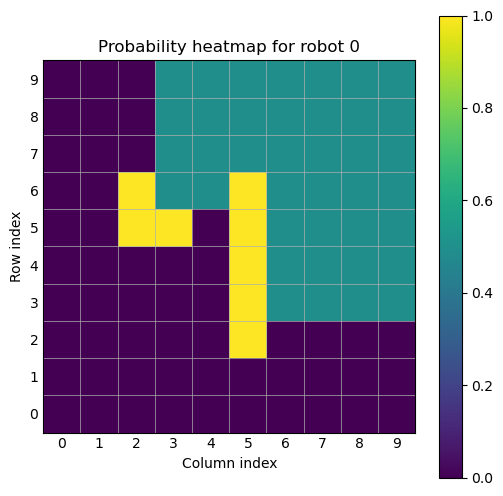

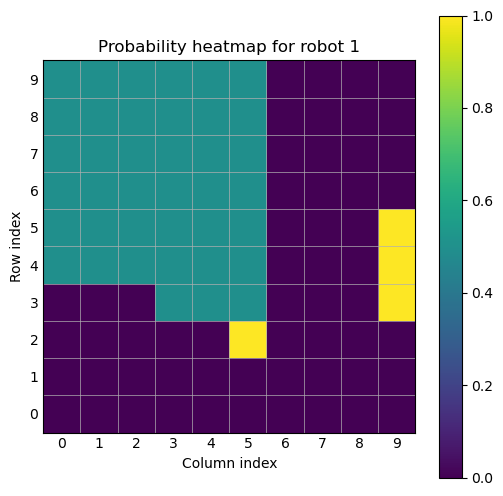

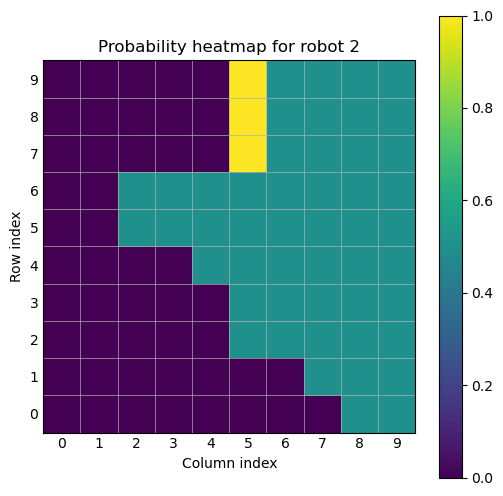

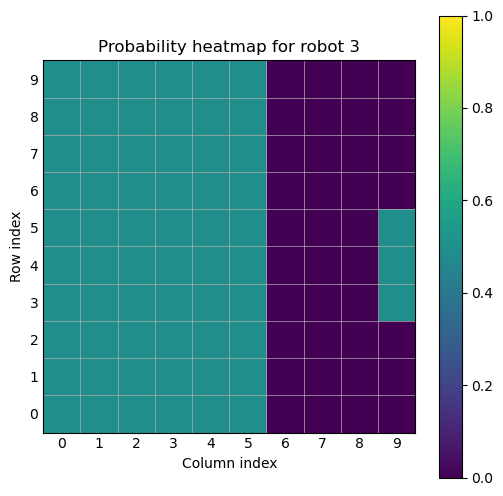

In [76]:
p0 = 0.5
p0log = np.log(p0/(1-p0))
x_lst = [p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10),p0log*np.ones_like(room_10x10)]

def simulate_non_cooperative_bayes(x_lst,K=20):
    for t in range(K):
        for i in range(4):
            xik = x_lst[i] 
            xik = bayes_step(i,xik)
            #xik = average(i,x_lst,w)
            x_lst[i] = xik
    return x_lst

x_lst = simulate_non_cooperative_bayes(x_lst)

p_lst = []
for i in range(4):
    p_lst.append(1/(1+np.exp(-x_lst[i])))

for i in range(4):
    plot_occupancy(p_lst[i],"Probability heatmap for robot " + str(i),cmap = "viridis")